# CheXzero training — stage-by-stage walkthrough

Follows one batch through the whole training path, printing **shape, dtype and value range**
at every stage, so you can see exactly what each step produces.

Stages: raw h5 → `__getitem__` → transforms → DataLoader → tokenizer → encoders →
normalize → similarity matrix → loss → gradients.

**Two notes before running**

1. Training may still be running. This notebook reads `cxr.h5` from the same HDD, so it will
   contend a little. It only touches a handful of rows, so the impact is small.
2. `DEVICE` below only controls where *tensors* go. `train.load_clip` hardcodes
   `torch.device("cuda:0" if torch.cuda.is_available() else "cpu")` internally and ignores it, so
   on this machine the weights are built on CUDA and **`model.float()` never fires** — they stay
   **fp16** even if you then move them to CPU. That is exactly what training runs, and Stage 6
   shows it.

In [1]:
import sys, os
import numpy as np, pandas as pd, torch, h5py
import matplotlib.pyplot as plt
from torch import nn
from torchvision.transforms import Compose, Normalize, Resize, InterpolationMode

CHEXZERO = "/mnt/My_Doc/github/xray_clip/CheXzero"
sys.path.insert(0, CHEXZERO)

CXR_H5  = f"{CHEXZERO}/data/cxr.h5"
TXT_CSV = f"{CHEXZERO}/data/mimic_impressions.csv"

DEVICE = "cpu"          # "cuda:0" to see the fp16 behaviour training actually uses
BATCH  = 8              # small on purpose; training uses 64
device = torch.device(DEVICE)
print("torch", torch.__version__, "| device:", device)

torch 2.6.0.dev20241112+cu121 | device: cpu


## Stage 1

`cxr.h5` : images

`mimic_impressions.csv` text.

In [7]:
h5   = h5py.File(CXR_H5, "r")
print(f"h5 file: {CXR_H5}, keys={list(h5.keys())}, items={list(h5.items())}")
dset = h5["cxr"]
txt  = pd.read_csv(TXT_CSV)

print(f"h5['cxr']      shape={dset.shape}  dtype={dset.dtype}  {dset.nbytes/1e9:.1f} GB")
print(f"impressions    rows={len(txt):,}  columns={list(txt.columns)}")
print(f"ALIGNED        {dset.shape[0] == len(txt)}")

i   = 0
raw = dset[i]
print(f"\nrow {i}: shape={raw.shape}  dtype={raw.dtype}  min={raw.min()}  max={raw.max()}")
print(f"  zero pixels (padding): {100*(raw==0).mean():.1f}%")
print(f"  paired text          : {txt['impression'][i]!r}")

h5 file: /mnt/My_Doc/github/xray_clip/CheXzero/data/cxr.h5, keys=['cxr'], items=[('cxr', <HDF5 dataset "cxr": shape (377110, 320, 320), type "|u1">)]
h5['cxr']      shape=(377110, 320, 320)  dtype=uint8  38.6 GB
impressions    rows=377,110  columns=['filename', 'impression']
ALIGNED        True

row 0: shape=(320, 320)  dtype=uint8  min=0  max=255
  zero pixels (padding): 19.4%
  paired text          : 'Compared to chest radiographs ___ through ___. No detectable pneumothorax. Small left pleural effusion if any. 2 left pleural drainage catheters in place. The pigtail is sharply folded as it enters the chest and may be effectively occluded. Moderate bibasilar atelectasis and small right pleural effusion are stable. Heart size normal.'


In [ ]:
# Look at the image itself to confirm preprocessing (square, letterboxed, right way up).
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
for ax, idx in zip(axes, [0, 1, 2, 3]):
    ax.imshow(dset[idx])
    # ax.imshow(dset[idx], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"row {idx}  {dset[idx].shape}", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

print("Note the black bands: preprocess() resizes the long side to 320 and zero-pads to square.")

NameError: name 'plt' is not defined

## Stage 2 — `CXRDataset.__getitem__`, step by step

`train.py:49-65`. Reproduced here one line at a time so each transformation is visible.
Watch the dtype change at `.float()` (our uint8 patch) and the channel count at `np.repeat`.

In [4]:
a = dset[i]
print(f"1. h5 read            {str(a.shape):18s} {a.dtype}   range [{a.min()}, {a.max()}]")

a = np.expand_dims(a, axis=0)
print(f"2. expand_dims        {str(a.shape):18s} {a.dtype}")

a = np.repeat(a, 3, axis=0)
print(f"3. repeat 3 channels  {str(a.shape):18s} {a.dtype}   (all 3 identical: "
      f"{np.array_equal(a[0], a[1])})")

t = torch.from_numpy(a).float()
print(f"4. from_numpy+.float  {str(tuple(t.shape)):18s} {t.dtype}   range [{t.min():.0f}, {t.max():.0f}]")
print("   ^ the .float() we added; torchvision Normalize rejects uint8 tensors")

1. h5 read            (320, 320)         uint8   range [0, 255]
2. expand_dims        (1, 320, 320)      uint8
3. repeat 3 channels  (3, 320, 320)      uint8   (all 3 identical: True)
4. from_numpy+.float  (3, 320, 320)      torch.float32   range [0, 255]
   ^ the .float() we added; torchvision Normalize rejects uint8 tensors


## Stage 3 — The transform pipeline

`train.py:83-88`. Two operations, and the normalization constants are **MIMIC's own statistics**
(mean 101.49, std 83.44) — not ImageNet's.

In [5]:
normalize = Normalize((101.48761,)*3, (83.43944,)*3)
resize    = Resize(224, interpolation=InterpolationMode.BICUBIC)

n = normalize(t)
print(f"after Normalize   {str(tuple(n.shape)):18s} {n.dtype}")
print(f"   range [{n.min():.3f}, {n.max():.3f}]  mean {n.mean():.3f}  std {n.std():.3f}")
print(f"   check: (0-101.49)/83.44 = {(0-101.48761)/83.43944:.3f}  <- what a black pixel becomes")

r = resize(n)
print(f"\nafter Resize      {str(tuple(r.shape)):18s} {r.dtype}")
print(f"   range [{r.min():.3f}, {r.max():.3f}]  mean {r.mean():.3f}")
print("   320 -> 224 because ViT-B/32 expects 224x224")

after Normalize   (3, 320, 320)      torch.float32
   range [-1.216, 1.840]  mean 0.018  std 0.996
   check: (0-101.49)/83.44 = -1.216  <- what a black pixel becomes

after Resize      (3, 224, 224)      torch.float32
   range [-1.384, 1.920]  mean 0.018
   320 -> 224 because ViT-B/32 expects 224x224


## Stage 4 — DataLoader: a batch

The real thing, via `load_data`. `shuffle=True` means the *pairing of negatives* changes every
epoch. `num_workers=0` means all of the above runs in the main process — the bottleneck we found.

In [6]:
from train import load_data, load_clip, preprocess_text

loader, _dev = load_data(CXR_H5, TXT_CSV, batch_size=BATCH, pretrained=True, column="impression")
batch = next(iter(loader))

imgs, raw_txts = batch["img"], batch["txt"]
print(f"\nbatch['img']  {str(tuple(imgs.shape)):22s} {imgs.dtype}   range [{imgs.min():.2f}, {imgs.max():.2f}]")
print(f"batch['txt']  list of {len(raw_txts)} strings\n")
for j, s in enumerate(raw_txts[:3]):
    print(f"  [{j}] {str(s)[:88]}")

Using CUDA.
Interpolation Mode:  InterpolationMode.BICUBIC
Finished image transforms for pretrained model.



batch['img']  (8, 3, 224, 224)       torch.float32   range [-1.36, 1.97]
batch['txt']  list of 8 strings

  [0] Cardiomegaly and pulmonary edema which may have progressed since prior although some cha
  [1] Patchy opacities in lung bases, likely atelectasis but infection is not excluded. Mild p
  [2] No acute cardiopulmonary process. If clinical concern for fracture, suggest dedicated im


## Stage 5 — Text → tokens

`train.py:159-175`. BPE-encode, wrap in `<|startoftext|>` / `<|endoftext|>`, pad or **truncate to
77 tokens** (position 76 is forcibly overwritten with EOT, so a clipped impression still ends
correctly).

In [7]:
model = load_clip(model_path=None, pretrained=True, context_length=77).to(device)
tokens = preprocess_text(raw_txts, model)

print(f"tokens  {str(tuple(tokens.shape)):16s} {tokens.dtype}   (batch, context_length)")

from simple_tokenizer import SimpleTokenizer
tk = SimpleTokenizer()
row = tokens[0]
n_real = int((row != 0).sum())
print(f"\nsample 0: {n_real} real tokens, {77-n_real} zero-padding")
print(f"  first 12 ids : {row[:12].tolist()}")
print(f"  decoded      : {tk.decode(row[1:n_real-1].tolist())!r}")

lens = [(t != 0).sum().item() for t in tokens]
print(f"\ntoken counts in batch: {lens}")
print(f"truncated (hit 77): {sum(l >= 77 for l in lens)} of {len(lens)}")

Loaded in pretrained model.
tokens  (8, 77)          torch.int64   (batch, context_length)



sample 0: 52 real tokens, 25 zero-padding
  first 12 ids : [49406, 6211, 3693, 2001, 344, 537, 39132, 29632, 1226, 1448, 1270, 720]
  decoded      : 'cardiomegaly and pulmonary edema which may have progressed since prior although some changes may be accounted for by lower lung volumes on the current exam . left basilar opacity , potentially atelectasis noting that infection would also be possible . '

token counts in batch: [52, 36, 23, 4, 26, 10, 10, 9]
truncated (hit 77): 0 of 8


## Stage 6 — The two encoders

Separate towers, same output width, so images and text land in one shared space.

**Watch the dtype.** On CPU everything is float32. On GPU, `convert_weights` leaves conv/linear/
attention weights in **fp16** while LayerNorms stay fp32 — that mixed state, with no `GradScaler`,
is what training actually runs.

In [8]:
dtypes = {}
for name, p in model.named_parameters():
    dtypes.setdefault(str(p.dtype), []).append(name)
print("parameter dtypes:")
for d, names in dtypes.items():
    print(f"  {d:15s} {len(names):3d} tensors   e.g. {names[0]}")

with torch.no_grad():
    img_f = model.encode_image(imgs.to(device))
    txt_f = model.encode_text(tokens.to(device))

print(f"\nencode_image  {str(tuple(img_f.shape)):16s} {img_f.dtype}")
print(f"encode_text   {str(tuple(txt_f.shape)):16s} {txt_f.dtype}")
print(f"\nembed_dim = {img_f.shape[1]} for both -> they share one space")

parameter dtypes:
  torch.float32   107 tensors   e.g. positional_embedding
  torch.float16   195 tensors   e.g. text_projection



encode_image  (8, 512)         torch.float16
encode_text   (8, 512)         torch.float16

embed_dim = 512 for both -> they share one space


## Stage 7 — Normalize, then the similarity matrix

`model.py:378-393`. After L2-normalization a dot product **is** cosine similarity, so
`img_f @ txt_f.T` gives a `(B, B)` matrix: entry `[i][j]` = how well image *i* matches report *j*.

`logit_scale` is a **learned** temperature, initialized to `log(1/0.07)` (`model.py:315`).

In [9]:
img_n = img_f / img_f.norm(dim=-1, keepdim=True)
txt_n = txt_f / txt_f.norm(dim=-1, keepdim=True)
print(f"norms after L2: image {img_n.norm(dim=-1)[:3].tolist()}  (all 1.0)")

scale = model.logit_scale.exp()
print(f"logit_scale: raw={model.logit_scale.item():.4f}  exp={scale.item():.3f}")
print(f"  model.py:315 initialises it to log(1/0.07)={np.log(1/0.07):.4f} for a FROM-SCRATCH model,")
print(f"  but we loaded OpenAI's pretrained weights, where it has already trained up to")
print(f"  ln(100)={np.log(100):.4f}. It keeps training from there.")

logits_per_image = scale * img_n @ txt_n.t()
logits_per_text  = scale * txt_n @ img_n.t()
print(f"\nlogits_per_image {str(tuple(logits_per_image.shape)):12s} <- (B, B) square")

sim = (img_n @ txt_n.t()).float().cpu().numpy()   # cosine, before scaling
print("\ncosine similarity matrix (rows=images, cols=texts), * marks the correct pair:")
print("      " + "".join(f"  txt{j}  " for j in range(min(6, BATCH))))
for r in range(min(6, BATCH)):
    cells = "".join(f" {sim[r,c]:+.3f}{'*' if r==c else ' '}" for c in range(min(6, BATCH)))
    print(f"img{r}  {cells}")

diag = np.diag(sim); off = sim[~np.eye(len(sim), dtype=bool)]
print(f"\ndiagonal (correct pairs) mean : {diag.mean():+.4f}")
print(f"off-diagonal (wrong pairs) mean: {off.mean():+.4f}")
print(f"gap: {diag.mean()-off.mean():+.4f}   <- training pushes this up")

norms after L2: image [1.0, 1.0, 1.0]  (all 1.0)
logit_scale: raw=4.6052  exp=100.000
  model.py:315 initialises it to log(1/0.07)=2.6593 for a FROM-SCRATCH model,
  but we loaded OpenAI's pretrained weights, where it has already trained up to
  ln(100)=4.6052. It keeps training from there.

logits_per_image (8, 8)       <- (B, B) square

cosine similarity matrix (rows=images, cols=texts), * marks the correct pair:
        txt0    txt1    txt2    txt3    txt4    txt5  
img0   +0.316* +0.297  +0.273  +0.182  +0.313  +0.287 
img1   +0.316  +0.293* +0.273  +0.179  +0.294  +0.279 
img2   +0.310  +0.284  +0.273* +0.175  +0.295  +0.289 
img3   +0.317  +0.303  +0.270  +0.174* +0.305  +0.286 
img4   +0.317  +0.300  +0.272  +0.176  +0.303* +0.288 
img5   +0.320  +0.309  +0.272  +0.177  +0.304  +0.291*

diagonal (correct pairs) mean : +0.2756
off-diagonal (wrong pairs) mean: +0.2750
gap: +0.0006   <- training pushes this up


## Stage 8 — The loss

`run_train.py:116-121`. The trick: correct pairs are on the diagonal, so "which report belongs to
image *i*?" is a B-way classification whose answer is always *i* — hence `torch.arange(B)`.

Computed **both directions** and averaged, so neither encoder can collapse.

In [10]:
criterion = nn.CrossEntropyLoss()
labels = torch.arange(imgs.shape[0]).to(device)
print(f"labels: {labels.tolist()}   <- 'image i matches text i'")

loss_img = criterion(logits_per_image, labels)
loss_txt = criterion(logits_per_text, labels)
loss = (loss_img + loss_txt) / 2

print(f"\nloss_img (image->text) {loss_img.item():.4f}")
print(f"loss_txt (text->image) {loss_txt.item():.4f}")
print(f"loss     (average)     {loss.item():.4f}")
print(f"\nchance for {imgs.shape[0]}-way classification = ln({imgs.shape[0]}) = {np.log(imgs.shape[0]):.4f}")

pred = logits_per_image.argmax(dim=1)
print(f"\npredicted match per image: {pred.tolist()}")
print(f"correct: {(pred == labels).sum().item()}/{len(labels)}")

print(f"""
Why is the loss ABOVE chance, and why does it predict one column for everything?

Look back at Stage 7: the diagonal/off-diagonal gap is ~0.0004 — CLIP has essentially no
idea which report goes with which X-ray, because it was trained on natural images.
But logit_scale is {scale.item():.0f}, so those near-identical cosines get multiplied into
logits that differ by several units. The softmax then becomes confidently WRONG rather
than uniform, and confident-and-wrong scores worse than chance.

This is the starting point CheXzero trains away from: the whole job is to open up that
diagonal gap. The real run began at ~4.16 (= ln 64) and is now ~2.85.""")
print(f"\nnegative pairs generated from {imgs.shape[0]} real pairs: "
      f"{imgs.shape[0]**2 - imgs.shape[0]} (free, no labels needed)")

labels: [0, 1, 2, 3, 4, 5, 6, 7]   <- 'image i matches text i'

loss_img (image->text) 4.5312
loss_txt (text->image) 2.1953
loss     (average)     3.3633

chance for 8-way classification = ln(8) = 2.0794

predicted match per image: [0, 0, 0, 0, 0, 0, 0, 0]
correct: 1/8

Why is the loss ABOVE chance, and why does it predict one column for everything?

Look back at Stage 7: the diagonal/off-diagonal gap is ~0.0004 — CLIP has essentially no
idea which report goes with which X-ray, because it was trained on natural images.
But logit_scale is 100, so those near-identical cosines get multiplied into
logits that differ by several units. The softmax then becomes confidently WRONG rather
than uniform, and confident-and-wrong scores worse than chance.

This is the starting point CheXzero trains away from: the whole job is to open up that
diagonal gap. The real run began at ~4.16 (= ln 64) and is now ~2.85.

negative pairs generated from 8 real pairs: 56 (free, no labels needed)


## Stage 9 — One optimizer step

`run_train.py:108-129`. Forward, both losses, backward, step. This is the entire training loop body.

In [11]:
opt = torch.optim.SGD(model.parameters(), lr=1e-4, momentum=0.9)

lpi, lpt = model(imgs.to(device), tokens.to(device))
l = (criterion(lpi, labels) + criterion(lpt, labels)) / 2
opt.zero_grad(); l.backward()

grads = [(n, p.grad) for n, p in model.named_parameters() if p.grad is not None]
total = torch.sqrt(sum((g.float()**2).sum() for _, g in grads))
finite = all(torch.isfinite(g).all().item() for _, g in grads)

print(f"loss {l.item():.4f}   params with grads: {len(grads)}")
print(f"global grad norm: {total.item():.4f}   all finite: {finite}")
print("\nsample gradients:")
for n, g in grads[:4]:
    print(f"  {n:42s} {str(tuple(g.shape)):18s} |g|={g.float().norm():.5f}")

before = model.logit_scale.item()
opt.step()
print(f"\nlogit_scale {before:.6f} -> {model.logit_scale.item():.6f}  (temperature is learned too)")
print("\nNo LR schedule, no warmup, no gradient clipping, no early stopping — this is the whole loop.")

loss 3.3633   params with grads: 302
global grad norm: 228.5530   all finite: True

sample gradients:
  positional_embedding                       (77, 512)          |g|=52.22763
  text_projection                            (512, 512)         |g|=51.26003
  logit_scale                                ()                 |g|=1.85261
  visual.class_embedding                     (768,)             |g|=6.14280

logit_scale 4.605170 -> 4.604985  (temperature is learned too)

No LR schedule, no warmup, no gradient clipping, no early stopping — this is the whole loop.


In [12]:
h5.close()
print("done")

done


---

# Results — CheXzero reproduction & benchmark comparison

**2026-09-14**

Trained CheXzero from scratch on MIMIC-CXR (377,110 image–report pairs, no labels), selected
checkpoints on CheXpert validation, and evaluated zero-shot on ChestX-ray14.

### Headline

| | |
|---|---|
| **Best zero-shot result (full NIH test, 14 labels)** | **0.6898** mean AUC |
| Same model on the benchmark's split (13,871 img, 9 labels) | **0.6370** |
| Benchmark ViT (ASL), *fully supervised*, same split | 0.8119 |
| Gap | **−0.175**, using **zero ChestX-ray14 labels** |

Four pathologies land within **0.054–0.059** of the supervised model. Five collapse toward
chance, and the reason is diagnosable — see *Interpretation*.

## 1. What was trained

Two runs. v1 reproduces the paper's configuration; v2 tests the two hypotheses v1 raised.

| | v1 | v2 |
|---|---|---|
| Epochs | 4 (paper) | **8** |
| Batch size | 64 (paper) | 64 |
| Optimiser | SGD, lr 1e-4, momentum 0.9 | same |
| Training text | impression only | **impression + FINDINGS fallback** |
| `"NO IMPRESSION"` rate | 15.1% | **4.4%** |
| Checkpoints | 236 | 236 |
| Ensemble spacing | none (top-10 raw) | **≥1000 steps** |
| Wall-clock | ~4.5 h | **~1.5 h** (h5 on NVMe + 8 dataloader workers) |

Why v2: in v1 **all ten** selected checkpoints came from epoch 4 and the best was the final one
saved — the signature of undertraining. And 15.1% of training pairs carried the literal string
`"NO IMPRESSION"`, i.e. ~9.7 identical texts per batch of 64, making the contrastive assignment
unsolvable for those rows.

In [13]:
import pandas as pd, numpy as np, os
os.chdir("/mnt/My_Doc/github/xray_clip")
D = "CheXzero/data"

v1  = pd.read_csv(f"{D}/nih_zeroshot_results.csv").set_index("label")      # 4ep, full test
b2  = pd.read_csv(f"{D}/nih_results_v2_baseline.csv").set_index("label")   # 8ep, baseline prompts
t2  = pd.read_csv(f"{D}/nih_results_v2_tuned.csv").set_index("label")      # 8ep, tuned prompts
r1  = pd.read_csv(f"{D}/checkpoint_ranking.csv")
r2  = pd.read_csv(f"{D}/checkpoint_ranking_v2.csv")

CHEX5 = ["Atelectasis","Cardiomegaly","Effusion","Consolidation","Edema"]
other9 = [l for l in v1.index if l not in CHEX5]

print(f"{'':36s}{'v1 (4ep)':>10}{'v2 (8ep)':>10}{'v2 tuned':>10}")
print("-"*66)
print(f"{'CheXpert val, 5 tasks (best ckpt)':36s}{r1.mean_auc.max():>10.4f}{r2.mean_auc.max():>10.4f}{'-':>10}")
print(f"{'NIH test, all 14 labels':36s}{v1.auc.mean():>10.4f}{b2.auc.mean():>10.4f}{t2.auc.mean():>10.4f}")
print(f"{'NIH test, 5 CheXpert labels':36s}{v1.loc[CHEX5].auc.mean():>10.4f}"
      f"{b2.loc[CHEX5].auc.mean():>10.4f}{t2.loc[CHEX5].auc.mean():>10.4f}")
print(f"{'NIH test, other 9 labels':36s}{v1.loc[other9].auc.mean():>10.4f}"
      f"{b2.loc[other9].auc.mean():>10.4f}{t2.loc[other9].auc.mean():>10.4f}")

                                      v1 (4ep)  v2 (8ep)  v2 tuned
------------------------------------------------------------------
CheXpert val, 5 tasks (best ckpt)       0.8449    0.8617         -
NIH test, all 14 labels                 0.6738    0.6685    0.6898
NIH test, 5 CheXpert labels             0.7607    0.7679    0.7740
NIH test, other 9 labels                0.6255    0.6132    0.6429


## 2. Did more training help?

**On CheXpert validation, yes. On ChestX-ray14, no.**

CheXpert val rose 0.845 → 0.862, but NIH test *fell* 0.6738 → 0.6685. Longer training kept
improving the features the selection criterion rewards while transfer to the target dataset
degraded slightly — overfitting to the selection domain.

The checkpoint steps confirm the undertraining question is now settled:

- **v1 (4 epochs):** all ten selected from epoch 4, best was the last saved → undertrained
- **v2 (8 epochs):** spread across epochs 4–8, none in the final stretch → **optimum found**

So 8 epochs is enough; going further will not help.

⚠️ **Caveat:** v1→v2 changed epochs *and* training text simultaneously, so the −0.005 cannot be
attributed to either alone. Isolating it needs a 4-epoch run on the fixed text.

In [14]:
from sklearn.metrics import roc_auc_score
from CheXzero.eval_nih import NIH_LABELS, build_groundtruth   # noqa

y = build_groundtruth("data/cxr8/Data_Entry_2017_v2020.csv",
                      f"{D}/nih_test_paths.csv", list(NIH_LABELS))
P = {k: np.load(f"{D}/{f}") for k, f in
     [("v1_4ep","nih_zeroshot_preds.npy"), ("v2_base","nih_preds_v2_baseline.npy"),
      ("v2_tuned","nih_preds_v2_tuned.npy")]}

rng = np.random.default_rng(0); n = len(y); B = 200
idxs = [rng.integers(0, n, n) for _ in range(B)]

def paired(a, b):
    """Bootstrap the mean-AUC difference, resampling the SAME images for both models."""
    d = []
    for i in idxs:
        yt = y[i]; ok = [j for j in range(yt.shape[1]) if 0 < yt[:,j].sum() < len(yt)]
        d.append(np.mean([roc_auc_score(yt[:,j], P[a][i][:,j]) for j in ok]) -
                 np.mean([roc_auc_score(yt[:,j], P[b][i][:,j]) for j in ok]))
    d = np.array(d); return d.mean(), np.percentile(d,2.5), np.percentile(d,97.5)

print(f"Paired bootstrap, {B} replicates (full NIH test, 14 labels)\n")
for a,b,desc in [("v2_base","v1_4ep","8ep + text fix   vs  4ep baseline"),
                 ("v2_tuned","v2_base","tuned prompts    vs  baseline prompts"),
                 ("v2_tuned","v1_4ep","BEST             vs  4ep baseline")]:
    m,lo,hi = paired(a,b)
    print(f"{desc:38s}{m:+.4f}   95% CI [{lo:+.4f}, {hi:+.4f}]   "
          f"{'significant' if (lo>0 or hi<0) else 'n.s.'}")

Paired bootstrap, 200 replicates (full NIH test, 14 labels)



8ep + text fix   vs  4ep baseline     -0.0053   95% CI [-0.0094, -0.0007]   significant


tuned prompts    vs  baseline prompts +0.0213   95% CI [+0.0188, +0.0243]   significant


BEST             vs  4ep baseline     +0.0160   95% CI [+0.0119, +0.0199]   significant


## 3. Prompt tuning — the largest single gain

CheXzero's inference prompt pair is `("{}", "no {}")`, so **the label string *is* the prompt**.
The paper uses bare dataset names. We searched 72 candidates (5–6 per label) and kept the best
per label.

**Selection was done on 20,000 images sampled from `train_val_list.txt` — disjoint from the test
set (verified zero overlap).** Tuning prompts on test AUC would invalidate the result.

Effect: **+0.0213 mean AUC, no retraining.** Credibility check: for 3 of 14 labels the search
*kept the baseline*, so it is not simply chasing noise.

In [15]:
sr = pd.read_csv(f"{D}/prompt_search_results_v2.csv")
best = sr.loc[sr.groupby("label")["auc"].idxmax()]
base = sr[sr.is_baseline]
m = (base[["label","prompt","auc"]].rename(columns={"prompt":"baseline","auc":"base_auc"})
     .merge(best[["label","prompt","auc"]].rename(columns={"prompt":"tuned","auc":"tuned_auc"}), on="label"))
m["delta"] = m.tuned_auc - m.base_auc
print("Prompt search on held-out train/val (positive prompt shown; negative is 'no <prompt>')\n")
print(m.sort_values("delta", ascending=False)[["label","baseline","tuned","base_auc","tuned_auc","delta"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\ncandidates tested: {len(sr)}   changed from baseline: {(m.baseline != m.tuned).sum()}/14")
print(f"held-out mean AUC: {m.base_auc.mean():.4f} -> {m.tuned_auc.mean():.4f}")

Prompt search on held-out train/val (positive prompt shown; negative is 'no <prompt>')

             label           baseline                            tuned  base_auc  tuned_auc  delta
            Nodule             Nodule      a chest x-ray with a nodule    0.5275     0.6209 0.0935
            Hernia             Hernia                    hiatal hernia    0.6434     0.7034 0.0600
Pleural_Thickening Pleural_Thickening               pleural thickening    0.6776     0.7064 0.0288
          Fibrosis           Fibrosis reticular interstitial opacities    0.5968     0.6178 0.0210
         Emphysema          Emphysema            emphysematous changes    0.6955     0.7101 0.0145
     Consolidation      Consolidation                    dense opacity    0.7698     0.7831 0.0133
       Atelectasis        Atelectasis              basilar atelectasis    0.7710     0.7829 0.0119
      Cardiomegaly       Cardiomegaly      enlarged cardiac silhouette    0.8381     0.8482 0.0100
      Infiltration   

## 4. Benchmark comparison — Mezina & Burget (2024)

*Detection of post-COVID-19-related pulmonary diseases in X-ray images using Vision
Transformer-based neural network*, Biomedical Signal Processing and Control 87:105380.

Their evaluation uses a **subset** of ChestX-ray14: 9 COVID-related pathologies, 13,871 test
images. We reproduced that split exactly — official `test_list.txt` filtered to images with ≥1
of the 9 diseases gives **13,871** (their figure), and the same filter on `train_val_list.txt`
gives **29,370** = their 23,496 train + 5,874 val. Both match to the image.

So the comparison below differs on **exactly one axis: supervision.**

| | Benchmark | Ours |
|---|---|---|
| ChestX-ray14 labels used in training | **23,496 labeled images** | **none** |
| Training signal | pixel labels | MIMIC radiology reports |
| Inference | trained classifier head | text prompts (zero-shot) |
| Test images | 13,871 | same 13,871 |

Note this split *excludes* the 9,861 "No Finding" images, since every image must carry ≥1
disease. Removing easy negatives lowers AUC for everyone — which is exactly why matching it
matters. Our score on these 9 pathologies drops from 0.7002 (full test set) to 0.6370 here.

In [16]:
bb = pd.read_csv(f"{D}/bench9_results_baseline.csv").set_index("label")
bt = pd.read_csv(f"{D}/bench9_results_tuned.csv").set_index("label")

# Mezina & Burget 2024, Table 2
paper = {"Cardiomegaly":(0.876,0.8875),"Consolidation":(0.665,0.6812),"Edema":(0.815,0.8230),
         "Effusion":(0.804,0.8126),"Emphysema":(0.897,0.8955),"Fibrosis":(0.827,0.8540),
         "Infiltration":(0.698,0.6966),"Nodule":(0.776,0.7829),"Pneumothorax":(0.862,0.8737)}
B9 = list(paper)
cmp = pd.DataFrame({
    "n_pos":   [int(bt.loc[l,"n_positive"]) for l in B9],
    "DenseNet121": [paper[l][0] for l in B9],
    "ViT_ASL":     [paper[l][1] for l in B9],
    "ours_base":   [bb.loc[l,"auc"] for l in B9],
    "ours_tuned":  [bt.loc[l,"auc"] for l in B9],
    "ci_lo":       [bt.loc[l,"ci_lower"] for l in B9],
    "ci_hi":       [bt.loc[l,"ci_upper"] for l in B9]}, index=B9)
cmp["gap"] = cmp.ours_tuned - cmp.ViT_ASL
cmp = cmp.sort_values("gap", ascending=False)

print("SAME 13,871 IMAGES, SAME 9 PATHOLOGIES  (supervised vs zero-shot)\n")
print(cmp.to_string(float_format=lambda v: f"{v:.4f}"))
print(f"\nMEAN   ViT(ASL) {cmp.ViT_ASL.mean():.4f}   ours {cmp.ours_tuned.mean():.4f}   "
      f"gap {cmp.ours_tuned.mean()-cmp.ViT_ASL.mean():+.4f}")

SAME 13,871 IMAGES, SAME 9 PATHOLOGIES  (supervised vs zero-shot)

               n_pos  DenseNet121  ViT_ASL  ours_base  ours_tuned  ci_lo  ci_hi     gap
Effusion        4658       0.8040   0.8126     0.7591      0.7591 0.7506 0.7675 -0.0535
Cardiomegaly    1069       0.8760   0.8875     0.8251      0.8317 0.8189 0.8450 -0.0558
Edema            925       0.8150   0.8230     0.7645      0.7645 0.7500 0.7793 -0.0585
Consolidation   1815       0.6650   0.6812     0.6086      0.6222 0.6085 0.6349 -0.0590
Infiltration    6112       0.6980   0.6966     0.6103      0.6011 0.5913 0.6106 -0.0955
Pneumothorax    2665       0.8620   0.8737     0.6616      0.6616 0.6498 0.6731 -0.2121
Nodule          1623       0.7760   0.7829     0.4442      0.5553 0.5388 0.5705 -0.2276
Fibrosis         435       0.8270   0.8540     0.4755      0.5039 0.4726 0.5344 -0.3501
Emphysema       1093       0.8970   0.8955     0.4329      0.4338 0.4173 0.4489 -0.4617

MEAN   ViT(ASL) 0.8119   ours 0.6370   gap -0.1749


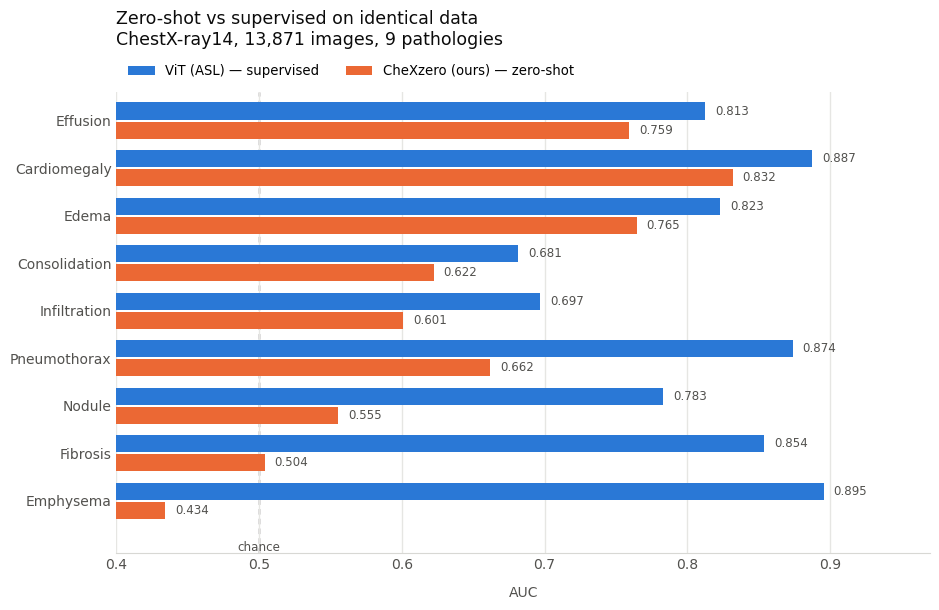

In [17]:
import matplotlib.pyplot as plt

# Categorical slots 1 and 2 from the data-viz reference palette, used in fixed order.
SUP, OURS = "#2a78d6", "#eb6834"
INK, MUTED = "#0b0b0b", "#52514e"

d = cmp.sort_values("gap")                      # widest gap at the bottom
ypos = np.arange(len(d)); h = 0.36

fig, ax = plt.subplots(figsize=(9.5, 6.2))
ax.barh(ypos + h/2 + 0.02, d.ViT_ASL,    height=h, color=SUP,  label="ViT (ASL) — supervised")
ax.barh(ypos - h/2 - 0.02, d.ours_tuned, height=h, color=OURS, label="CheXzero (ours) — zero-shot")

for y, (v, o) in enumerate(zip(d.ViT_ASL, d.ours_tuned)):
    ax.text(v + .007, y + h/2 + 0.02, f"{v:.3f}", va="center", fontsize=8.5, color=MUTED)
    ax.text(o + .007, y - h/2 - 0.02, f"{o:.3f}", va="center", fontsize=8.5, color=MUTED)

ax.axvline(0.5, color=MUTED, lw=1, ls=(0, (4, 3)), zorder=0)
ax.text(0.5, -0.85, "chance", ha="center", va="top", fontsize=8.5, color=MUTED)

ax.set_yticks(ypos); ax.set_yticklabels(d.index, fontsize=10)
ax.set_ylim(-1.1, len(d) - 0.4)
ax.set_xlim(0.4, 0.97); ax.set_xlabel("AUC", fontsize=10, color=MUTED, labelpad=10)
ax.set_title("Zero-shot vs supervised on identical data\n"
             "ChestX-ray14, 13,871 images, 9 pathologies",
             fontsize=12.5, color=INK, loc="left", pad=34)
# legend above the plot: inside the axes it collided with the widest bars
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.005), ncol=2, frameon=False, fontsize=9.5)
ax.xaxis.grid(True, color="#e6e6e3", lw=1); ax.set_axisbelow(True)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#d8d8d4"); ax.tick_params(length=0, colors=MUTED)
plt.tight_layout(); plt.show()

## 5. Interpretation — the two-group story

**Group A — competitive without labels.** Cardiomegaly, Effusion, Edema, Consolidation and
Infiltration sit **0.054–0.096** below a fully supervised ViT. For a model that never saw a
ChestX-ray14 label, that is the result worth leading with.

**Group B — near chance.** Emphysema (0.434), Fibrosis (0.504) and Nodule (0.555) collapse.
Radiologists rarely name literally in MIMIC impressions.

## 6. What to do next

| Priority | Action | Cost | Rationale |
|---|---|---|---|
| 1 | Select checkpoints on **all 14 CheXpert labels**, not 5 | ~15 min, no retraining | The other 9 NIH labels score 0.643 vs 0.774 for the selected 5 — selection is the likely cause |
| 2 | Widen the prompt search for Group B, incl. descriptive phrases | ~30 min, no retraining | Prompts already bought +0.021; Nodule alone gained +0.111 |
| 3 | 4-epoch run on the fixed text | ~1 h | Separates the epoch effect from the text effect, currently confounded |
| 4 | Frontal-only MIMIC training | preprocessing + 1.5 h | ChestX-ray14 is all frontal; MIMIC is ~25% lateral |

Reproducibility: both models retained — `checkpoints/pt-imp-v1/` (4 epoch) and
`checkpoints/pt-imp/` (8 epoch) — each with its own ranking CSV.